In [3]:
import numpy as np
from datashader.bundling import hammer_bundle
from shapely import wkt
import pandas as pd

# — 1) Load and parse (as before) —
df = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/clean_movement_hotels.csv")
df = df.drop_duplicates(subset = ["place_id_hotel", "place_id_visited"])
df["geometry"] = df["movement_line"].apply(wkt.loads)

# Project to meters
import geopandas as gpd
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs(epsg=3857)




In [7]:
# — 3) Build your paths list as before —
paths = [list(line.coords) for line in gdf.geometry]

# — 4) Build the unique node_index & edges list as before —
node_index = {}
edges = []
for i, coords in enumerate(paths):
    start, end = tuple(coords[0]), tuple(coords[-1])
    for pt in (start, end):
        if pt not in node_index:
            node_index[pt] = len(node_index)
    edges.append((node_index[start], node_index[end]))
edges = np.array(edges, dtype=int)

# — 5) Convert node_index → a structured NumPy array of (x,y) —
#    The iᵗʰ entry in `nodes` must have fields 'x' and 'y' so the bundler can do
#    np.min(nodes['x']) etc.
#    We create a list sorted by the index we assigned above:
node_list = [None] * len(node_index)
for (x, y), idx in node_index.items():
    node_list[idx] = (x, y)

#nodes = np.array(node_list, dtype=[('x', 'f8'), ('y', 'f8')])

# — 6) (Optional) your visit‐counts as weights —
#weights = gdf["visits"].to_numpy()

# 1) Build nodes_df: index = node_id, columns 'x','y'
nodes_df = pd.DataFrame(node_list, columns=['x','y'])
# By default its index is 0..len(node_list)-1, which matches your node_ids

# 2) Build edges_df (as before)
edges_df = pd.DataFrame(edges, columns=['source','target'])

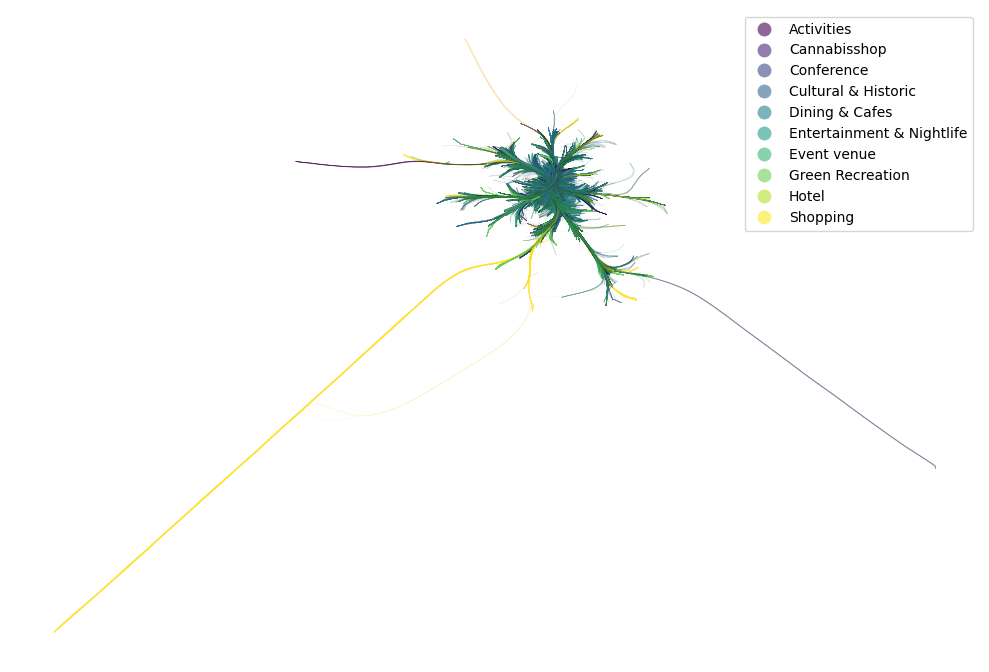

In [11]:
# (2) Run the bundler once, *no* weights/weighting argument:
hb = hammer_bundle(nodes_df, edges_df)
#    hb is now a DataFrame with columns 'x','y' and NaN-rows between each edge

# (3) Grab the raw x,y array and find the NaN separators
coords = hb[['x','y']].values
nan_idx = np.where(np.isnan(coords[:,0]))[0]

# (4) Slice out each segment into a list of (n,2) arrays
segments = []
start = 0
for idx in nan_idx:
    seg = coords[start:idx]   # points for one bundled edge
    if len(seg):
        segments.append(seg)
    start = idx + 1
# If the last segment doesn’t end with NaN, you may need to append coords[start:]

# (5) Build Shapely LineStrings from each segment
line_geoms = [LineString(seg) for seg in segments]

# (6) Reconstruct a GeoDataFrame, aligning one segment per original row
bundled_gdf = gpd.GeoDataFrame({
    'visits':   gdf['visits'].values,      # length must match len(segments)
    'category': gdf['category'].values,
    'geometry': line_geoms
}, crs=gdf.crs)


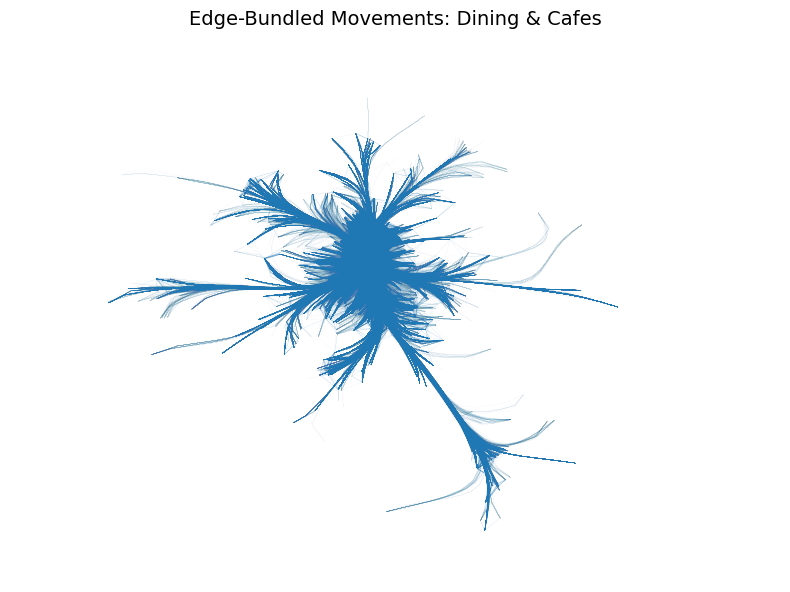

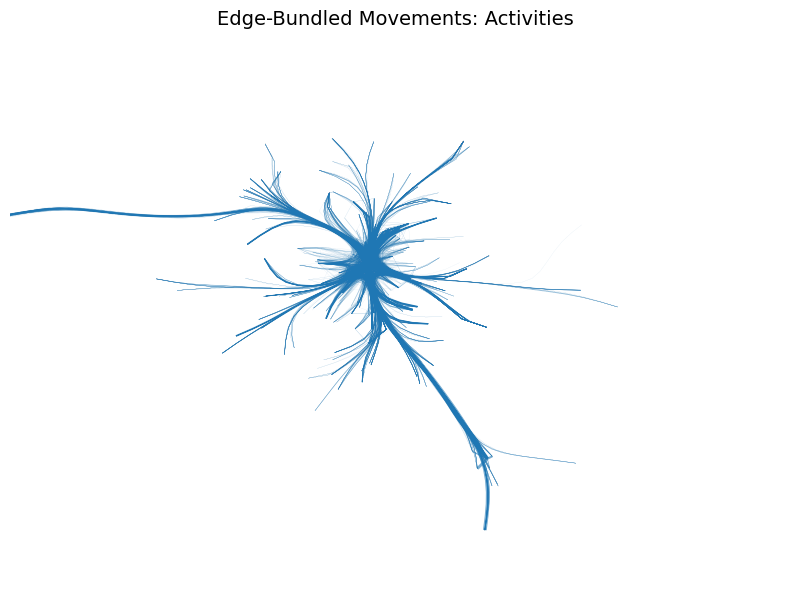

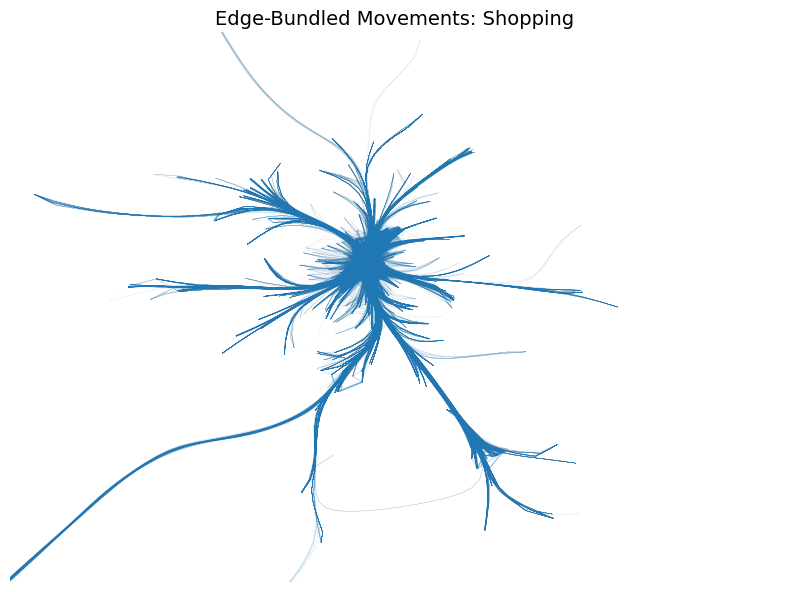

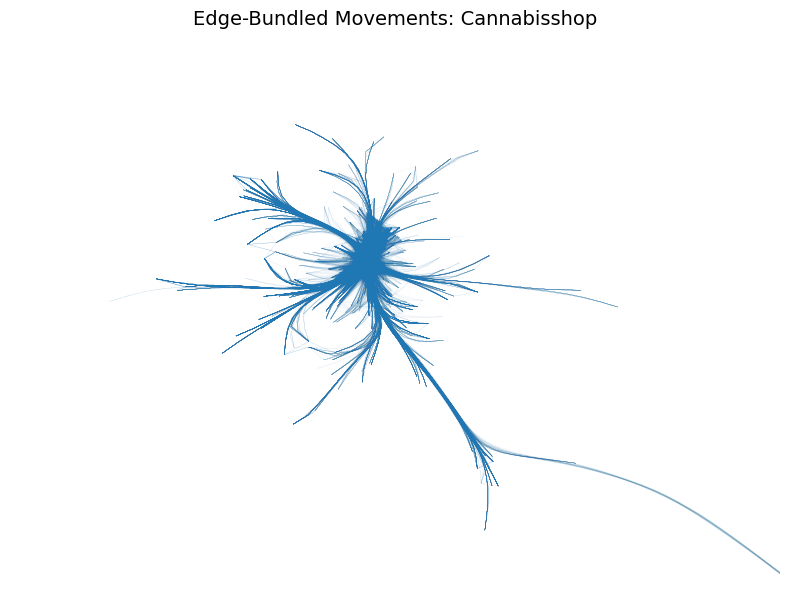

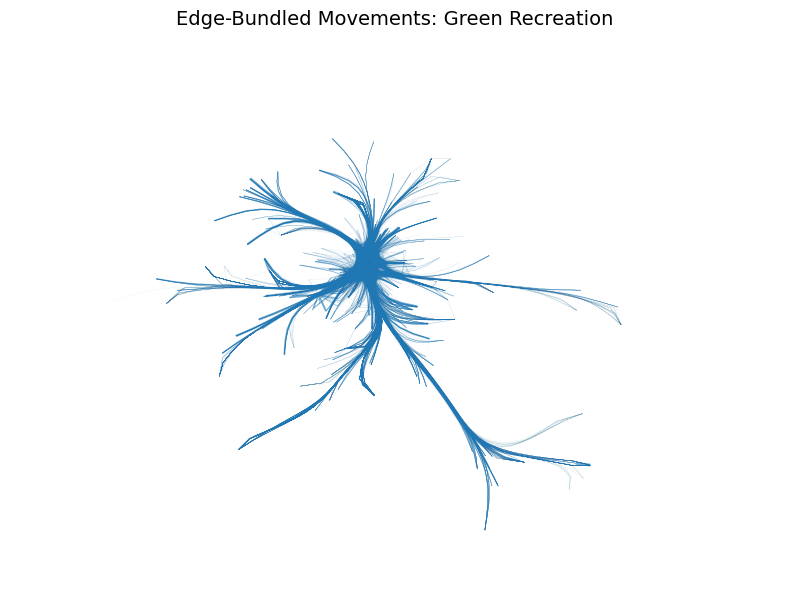

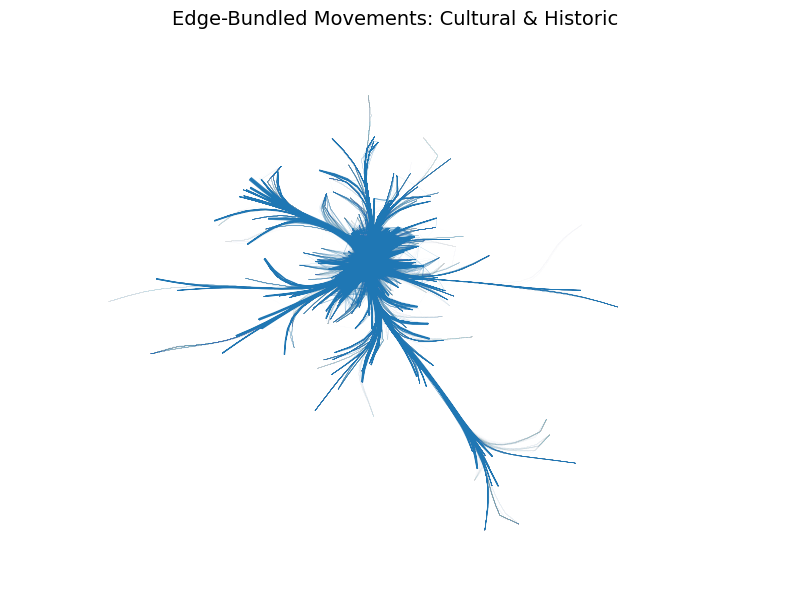

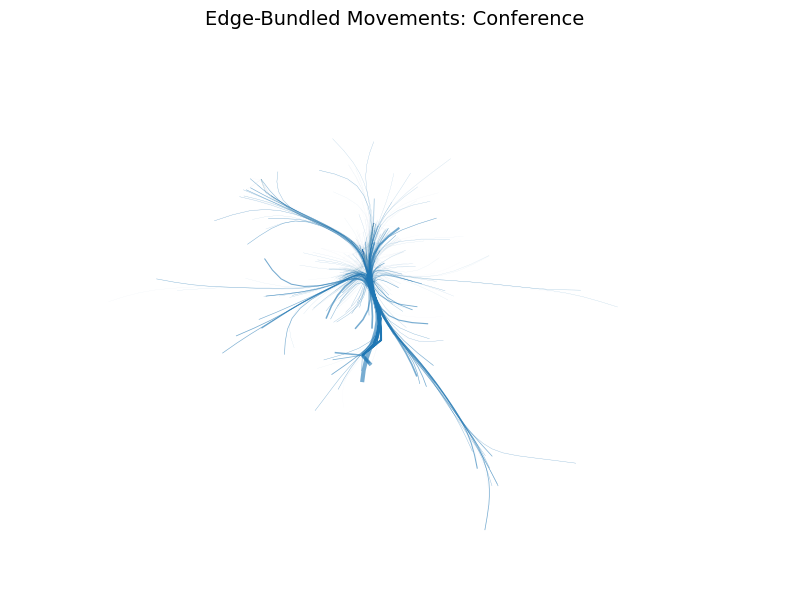

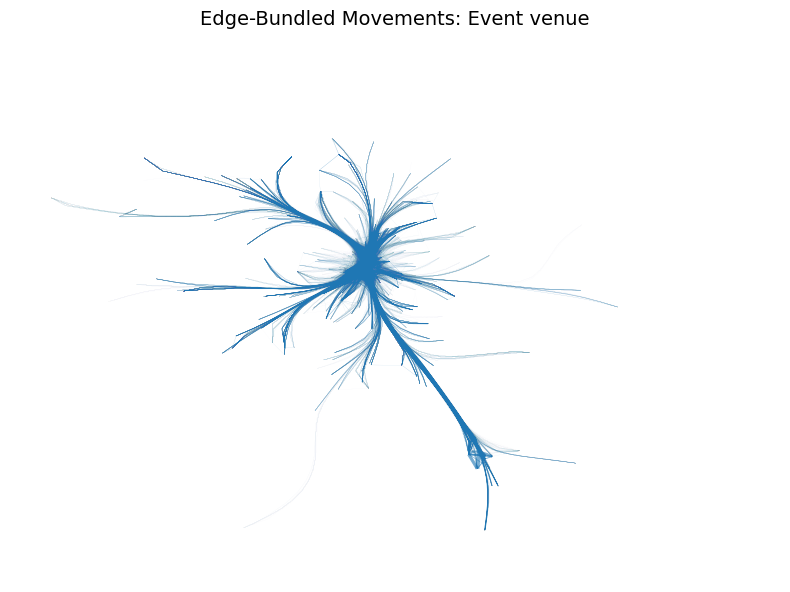

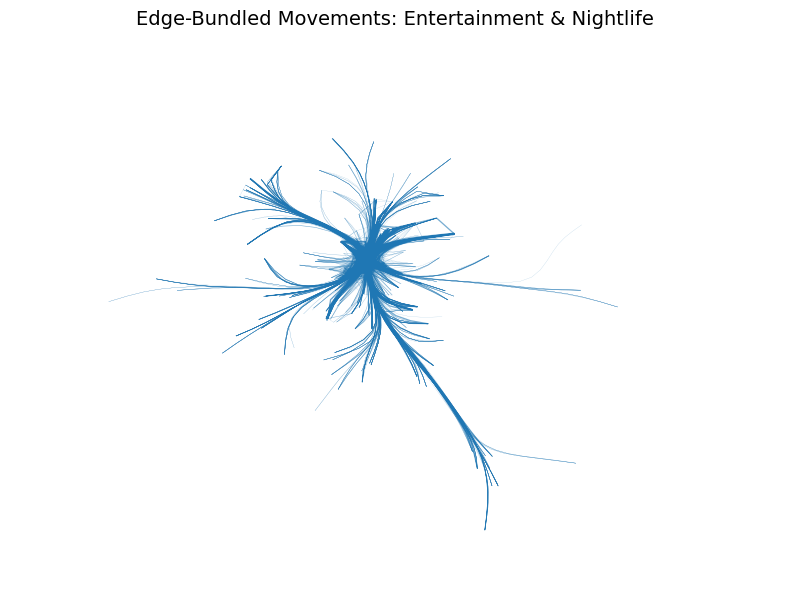

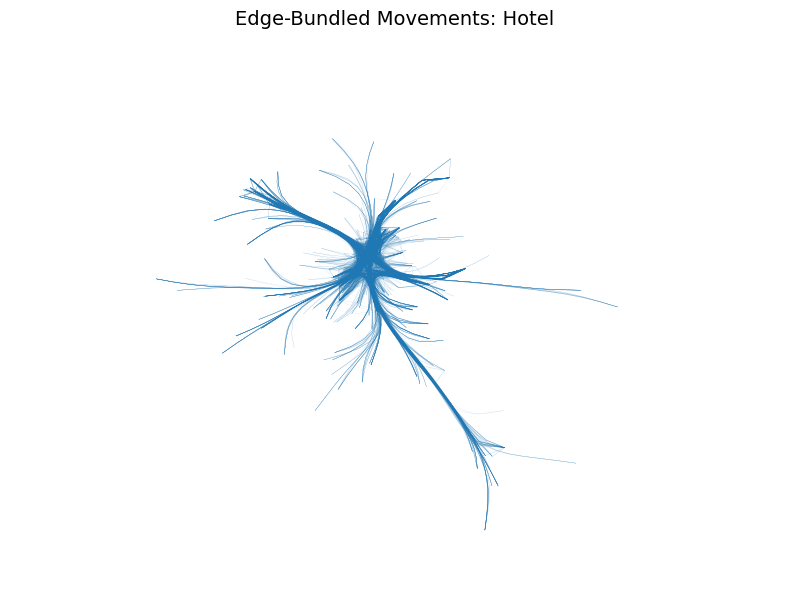

In [12]:
import matplotlib.pyplot as plt
from shapely.geometry import box
import geopandas as gpd

# 1. Define an Amsterdam bbox in WGS84 (lat/lon):
#    roughly [4.728°E, 5.079°E] × [52.278°N, 52.431°N]
amsterdam_bbox = box(4.728, 52.278, 5.079, 52.431)

# 2. Project that bbox into your bundled_gdf CRS (EPSG:3857)
bbox_gdf = gpd.GeoSeries([amsterdam_bbox], crs="EPSG:4326").to_crs(bundled_gdf.crs)
xmin, ymin, xmax, ymax = bbox_gdf.total_bounds

# 3. Loop over each category and plot
for cat in bundled_gdf['category'].unique():
    subset = bundled_gdf[bundled_gdf['category'] == cat]
    
    fig, ax = plt.subplots(figsize=(8,8))
    subset.plot(
        ax=ax,
        linewidth=subset['visits'] / subset['visits'].max() * 3,
        alpha=0.6
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"Edge‐Bundled Movements: {cat}", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [13]:
# Export each category into its own layer in a single .gpkg
for cat in bundled_gdf['category'].unique():
    subset = bundled_gdf[bundled_gdf['category'] == cat]
    layer_name = cat.replace(' ', '_')  # no spaces in layer names
    subset.to_file(
        "bundled_movements.gpkg",
        layer=layer_name,
        driver="GPKG"
    )